# 07 — As quatro dimensões num só plot

**Pergunta deste notebook:** *e se a gente conseguisse ler precisão, concisão, latência e custo de cada modelo num único gráfico, sem perder nuance?*

O `05_sintese` separa as dimensões em painéis. Útil para aprofundar. Aqui é o oposto: **um plot só**, denso, para a visão de conjunto — o tipo de figura que cabe num slide.

A ideia é simples:

- **Eixo Y → precisão** (média de `avaliacao_final`)
- **Eixo X → concisão** (média de `concisao_score`)
- **Cor da metade esquerda do marcador → latência média**
- **Cor da metade direita do marcador → custo médio por consulta** (escala log)

A forma do marcador separa as duas origens:

- **Bolinha** = resposta via API instrumentada (`origem_resultado = ferramenta`)
- **Quadrado** = resposta via chat web (`origem_resultado = chat_comercial`)

Para o chat web, o custo é tratado como **0,00 USD** (não há cobrança no fluxo do usuário) e a latência fica em **cinza neutro** — ela não foi medida.

Quanto mais ao **canto superior-direito** e mais **verde** nas duas metades, melhor.


In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Rectangle
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
import matplotlib.transforms as mtransforms

from utils import carregar_dados, estilo_padrao, ORDEM_MODELOS, titulo_acima

estilo_padrao()
df = carregar_dados()

## 1. Agregação por modelo

Uma linha por modelo, média das quatro métricas. Os modelos de chat web não têm `custo_estimado_usd` nem `latencia_s` medidos — convertemos custo para 0 (regra combinada) e mantemos latência como `NaN`.


In [2]:
def media_safe(s):
    return s.mean() if s.notna().any() else np.nan

mestre = (df.groupby('modelo_display')
            .agg(precisao   = ('avaliacao_final',    'mean'),
                 concisao   = ('concisao_score',     'mean'),
                 latencia_s = ('latencia_s',         media_safe),
                 custo_usd  = ('custo_estimado_usd', media_safe),
                 familia    = ('familia',            'first'),
                 origem     = ('origem_resultado',   'first'))
            .loc[ORDEM_MODELOS]
            .copy())

# Regra combinada: chat web nao tem custo de API -> custo 0 para fins de cor
mestre['custo_plot'] = mestre['custo_usd'].fillna(0.0)

# Tabela de apoio (numeros crus por tras do grafico)
apoio = mestre[['precisao','concisao','latencia_s','custo_usd','origem']].copy()
apoio['precisao']   = (apoio['precisao']*100).round(1).astype(str) + '%'
apoio['concisao']   = (apoio['concisao']*100).round(1).astype(str) + '%'
apoio['latencia_s'] = apoio['latencia_s'].round(1)
apoio['custo_usd']  = apoio['custo_usd'].round(4)
apoio

,precisao,concisao,latencia_s,custo_usd,origem
modelo_display,,,,,
GPT-4o mini,91.0%,88.7%,5.6,0.0014,ferramenta
GPT-5.4 mini,90.7%,99.3%,2.9,0.0060,ferramenta
GPT-5.4,96.3%,97.3%,5.7,0.0236,ferramenta
GPT-5.5,99.7%,97.3%,21.3,0.0547,ferramenta
Claude Haiku 4.5,93.7%,53.3%,17.5,0.0172,ferramenta
Claude Sonnet 4.6,97.3%,36.0%,12.9,0.0538,ferramenta
Claude Opus 4.7,97.7%,48.7%,12.3,0.1070,ferramenta
DeepSeek v4 Flash,97.0%,56.0%,8.6,0.0020,ferramenta
DeepSeek v4 Pro,96.3%,47.3%,17.9,0.0250,ferramenta


## 2. O gráfico

Marcadores pequenos, divididos verticalmente ao meio. Cada metade usa sua própria paleta sequencial monocromática:

- **Latência → azul slate** (claro = rápido, escuro = lento)
- **Custo → terracota** (claro = barato, escuro = caro)

A convenção é a mesma para as duas: **claro = bom, escuro = ruim**. Isso permite a leitura visual imediata — um marcador com as duas metades claras é um modelo rápido E barato; um marcador escuro dos dois lados é o oposto. Não é preciso consultar a legenda para cada ponto.

O custo entra em escala log porque a faixa é de 75× entre o mais barato e o mais caro; sem log, todos os modelos baratos teriam praticamente a mesma cor.


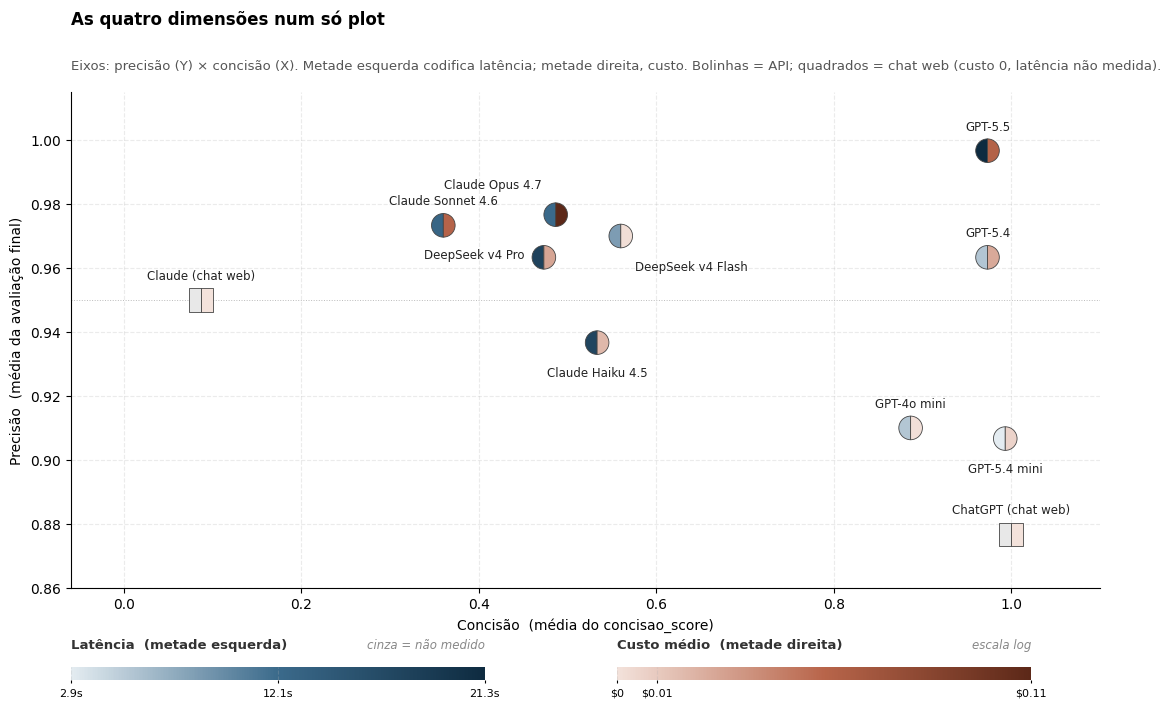

In [3]:
# Paletas sequenciais distintas: claro = bom, escuro = ruim.
# Azul slate para latência (frio, "tempo escorrendo"),
# terracota para custo (quente, "queima dinheiro").
cmap_lat  = LinearSegmentedColormap.from_list('lat',
    ['#E4ECF1', '#3B6A8B', '#0E2B40'])
cmap_cost = LinearSegmentedColormap.from_list('cost',
    ['#F3E2DB', '#B8654A', '#5C2818'])

# Custo em log1p para acomodar o 0 do chat web na mesma escala
custo_log  = np.log1p(mestre['custo_plot'])
norm_custo = Normalize(vmin=custo_log.min(), vmax=custo_log.max())

# Latência só nos valores medidos (ferramenta)
lat_validas = mestre['latencia_s'].dropna()
norm_lat = Normalize(vmin=lat_validas.min(), vmax=lat_validas.max())

COR_NAO_MEDIDA = '#E8E8E8'  # cinza neutro para latencia do chat web

fig, ax = plt.subplots(figsize=(11.5, 7.4))
ax.set_xlim(-0.06, 1.1)
ax.set_ylim(0.86, 1.015)

RAIO_PT = 8.5  # raio do marcador em pontos

# Truque: marcador com tamanho em PONTOS (nao em unidades de eixo).
# Definimos a forma em coords de "ponto" e usamos PatchCollection com offsets em data.
trans_pt = (mtransforms.Affine2D().scale(1/72.0) + fig.dpi_scale_trans)

# Quatro listas: bolinha-esq, bolinha-dir, quadrado-esq, quadrado-dir
pe, pd_, qe, qd = [], [], [], []
ce, cd, qce, qcd = [], [], [], []
oe, oq = [], []

for _, row in mestre.iterrows():
    x, y = row['concisao'], row['precisao']
    cl = cmap_lat(norm_lat(row['latencia_s'])) if pd.notna(row['latencia_s']) else COR_NAO_MEDIDA
    cc = cmap_cost(norm_custo(np.log1p(row['custo_plot'])))
    r = RAIO_PT
    if row['origem'] == 'chat_comercial':
        qe.append(Rectangle((-r,-r), r, 2*r))
        qd.append(Rectangle((0,-r),  r, 2*r))
        qce.append(cl); qcd.append(cc); oq.append((x, y))
    else:
        pe.append(Wedge((0,0), r, 90, 270))
        pd_.append(Wedge((0,0), r, -90, 90))
        ce.append(cl); cd.append(cc); oe.append((x, y))

def add(patches, cores, offs):
    if not patches: return
    ax.add_collection(PatchCollection(
        patches, facecolors=cores, edgecolors='#444', linewidths=0.6,
        offsets=offs, transOffset=ax.transData,
        transform=trans_pt, zorder=4))

add(pe, ce, oe);  add(pd_, cd, oe)
add(qe, qce, oq); add(qd, qcd, oq)

# Rótulos: offsets manuais para evitar sobreposição (Opus e Flash estão próximos)
offsets_lab = {
    'GPT-5.5':            ( 0,  13, 'center', 'bottom'),
    'GPT-5.4':            ( 0,  13, 'center', 'bottom'),
    'GPT-5.4 mini':       ( 0, -17, 'center', 'top'),
    'GPT-4o mini':        ( 0,  13, 'center', 'bottom'),
    'Claude Opus 4.7':    (-10, 17, 'right',  'bottom'),
    'Claude Sonnet 4.6':  ( 0,  13, 'center', 'bottom'),
    'Claude Haiku 4.5':   ( 0, -17, 'center', 'top'),
    'DeepSeek v4 Flash':  ( 10,-17, 'left',   'top'),
    'DeepSeek v4 Pro':    (-14,  2, 'right',  'center'),
    'ChatGPT (chat web)': ( 0,  13, 'center', 'bottom'),
    'Claude (chat web)':  ( 0,  13, 'center', 'bottom'),
}
for nome, row in mestre.iterrows():
    dx, dy, ha, va = offsets_lab.get(nome, (0, 13, 'center', 'bottom'))
    ax.annotate(nome, xy=(row['concisao'], row['precisao']),
                xytext=(dx, dy), textcoords='offset points',
                ha=ha, va=va, fontsize=8.5, color='#222')

ax.axhline(0.95, ls=':', color='#bbb', lw=0.7, zorder=1)
ax.set_xlabel('Concisão  (média do concisao_score)')
ax.set_ylabel('Precisão  (média da avaliação final)')

titulo_acima(ax, 'As quatro dimensões num só plot',
    'Eixos: precisão (Y) × concisão (X). Metade esquerda codifica latência; metade direita, custo. '
    'Bolinhas = API; quadrados = chat web (custo 0, latência não medida).')

# Duas colorbars horizontais no rodapé, paletas distintas
fig.subplots_adjust(top=0.88, bottom=0.21, left=0.075, right=0.97)

cax_lat  = fig.add_axes([0.075, 0.085, 0.36, 0.018])
cax_cost = fig.add_axes([0.55,  0.085, 0.36, 0.018])

sm_l = ScalarMappable(norm=norm_lat, cmap=cmap_lat); sm_l.set_array([])
cb_l = fig.colorbar(sm_l, cax=cax_lat, orientation='horizontal')
tk_l = [norm_lat.vmin, (norm_lat.vmin+norm_lat.vmax)/2, norm_lat.vmax]
cb_l.set_ticks(tk_l); cb_l.set_ticklabels([f'{v:.1f}s' for v in tk_l])
cb_l.ax.tick_params(labelsize=8, length=2); cb_l.outline.set_visible(False)
cax_lat.text(0,   2.4, 'Latência  (metade esquerda)',
    transform=cax_lat.transAxes, fontsize=9.5, color='#333', ha='left', weight='bold')
cax_lat.text(1.0, 2.4, 'cinza = não medido',
    transform=cax_lat.transAxes, fontsize=8.5, color='#888', ha='right', style='italic')

sm_c = ScalarMappable(norm=norm_custo, cmap=cmap_cost); sm_c.set_array([])
cb_c = fig.colorbar(sm_c, cax=cax_cost, orientation='horizontal')
ticks_usd = [0.000, 0.010, 0.107]
cb_c.set_ticks([np.log1p(v) for v in ticks_usd])
cb_c.set_ticklabels(['$0', '$0.01', '$0.11'])
cb_c.ax.tick_params(labelsize=8, length=2); cb_c.outline.set_visible(False)
cax_cost.text(0,   2.4, 'Custo médio  (metade direita)',
    transform=cax_cost.transAxes, fontsize=9.5, color='#333', ha='left', weight='bold')
cax_cost.text(1.0, 2.4, 'escala log',
    transform=cax_cost.transAxes, fontsize=8.5, color='#888', ha='right', style='italic')

plt.show()

## 3. Como ler

A regra única: **quanto mais claras as duas metades, melhor o modelo nas dimensões invisíveis aos eixos**. Marcador escuro do lado azul = lento; marcador escuro do lado terracota = caro.

**Canto superior-direito é o lugar desejado** — precisão alta, concisão alta:

- **GPT-5.5** — o ponto mais alto e à direita; precisão 99,7%, concisão 97,3%. Mas as duas metades **escuras**: a latência (21,3s) é a pior do conjunto e o custo é alto. O melhor do mundo se o tempo não importa.
- **GPT-5.4** — quase tão à direita, precisão um pouco menor (96,3%), **duas metades claras**: rápido e barato. O melhor compromisso da família OpenAI.
- **GPT-5.4 mini** — concisão quase perfeita, latência mais clara possível (2,9s, a menor do estudo), custo ainda baixo. Pena a precisão (90,7%).

**O canto superior-esquerdo é o território Claude (API)** — `Sonnet 4.6` e `Opus 4.7` têm precisão alta mas concisão **muito** baixa (36% e 49%). E, no caso do `Opus`, a metade da direita é o terracota mais escuro do plot: é o modelo mais caro do estudo. Visualmente, é um marcador escuro-dos-dois-lados num canto pouco amigável do plot.

**DeepSeek v4 Flash** é um caso curioso: senta no centro com precisão 97% e concisão modesta (56%), mas com as **duas metades quase no claro extremo**. É o modelo mais barato (US$ 0,002) e rápido o suficiente. Para uso de alto volume com tolerância à concisão menor, é a escolha óbvia.

**Os quadrados (chat web):**

- **ChatGPT (chat web)** — quadrado lá embaixo à direita: concisão máxima (1,00), precisão a mais baixa do estudo (87,7%). Lado direito no claro (custo 0); lado esquerdo cinza (latência não medida).
- **Claude (chat web)** — quadrado no extremo esquerdo: concisão quase nula (0,09 — o chat web do Claude escreve respostas longuíssimas). Precisão razoável (95,0%).

O contraste é interessante: **a interface web altera o comportamento do modelo de forma drástica em relação à API**, em direções opostas para cada família.


## 4. O que este plot resolve

Em três frases:

1. **A escolha não está num eixo**: ninguém é melhor em tudo. GPT-5.5 ganha em precisão; GPT-5.4 mini, em latência; DeepSeek v4 Flash, em custo; ChatGPT chat, em concisão. Cada um paga em alguma outra dimensão.
2. **Família importa**: Claude (API) ocupa o canto esquerdo do plot (concisão baixa) e DeepSeek ocupa o centro-esquerda; OpenAI fica à direita. Esse padrão sobrevive entre modelos de tamanhos diferentes da mesma família.
3. **Chat web ≠ API, e nem sempre na mesma direção**: o ChatGPT-chat fica mais conciso e menos preciso que sua API; o Claude-chat fica menos conciso e similar em precisão. Ou seja, o canal influencia o comportamento, mas não de forma consistente entre fornecedores.

O `05_sintese` continua sendo a leitura recomendada para quem precisa **decidir**. Este notebook é a leitura recomendada para quem precisa **mostrar**.
